In [1]:
import numpy as np
import missingno as mno
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import regression

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

In [2]:
# dataset from https://archive.ics.uci.edu/dataset/360/air+quality
df = pd.read_csv("daten/AirQualityUCI.csv", delimiter=";")

In [3]:
# Date	0 Date
# Time	1 Time
# CO(GT) True hourly averaged concentration CO in mg/m^3  (reference analyzer)
# PT08.S1(CO) PT08.S1 (tin oxide)  hourly averaged sensor response (nominally  CO targeted)
# NMHC(GT) True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 (reference analyzer)
# C6H6(GT) True hourly averaged Benzene concentration  in microg/m^3 (reference analyzer)
# PT08.S2(NMHC) PT08.S2 (titania) hourly averaged sensor response (nominally NMHC targeted)
# NOx(GT) True hourly averaged NOx concentration  in ppb (reference analyzer)
# PT08.S3(NOx) PT08.S3 (tungsten oxide) hourly averaged sensor response (nominally NOx targeted) 
# NO2(GT) True hourly averaged NO2 concentration in microg/m^3 (reference analyzer)
# PT08.S4(NO2) PT08.S4 (tungsten oxide) hourly averaged sensor response (nominally NO2 targeted)
# PT08.S5(O3) PT08.S5 (indium oxide) hourly averaged sensor response (nominally O3 targeted)
# T Temperature in °C
# RH Relative Humidity (%) 
# AH Absolute Humidity


In [4]:
# rename columns for easier handling
df = df.rename(columns={
    'C6H6(GT)': 'benzene',
    'CO(GT)': 'CO',
    'NMHC(GT)': 'NMHC',
    'NOx(GT)': 'NOx',
    'NO2(GT)': 'NO2',
    'PT08.S1(CO)': 's1_CO',
    'PT08.S2(NMHC)': 's2_NMHC',
    'PT08.S3(NOx)': 's3_NOx',
    'PT08.S4(NO2)': 's4_NO2',
    'PT08.S5(O3)': 's5_O3'
})

In [5]:
# Entferne überschüssige Spalten
df = df.drop("Unnamed: 15", axis=1)
df = df.drop("Unnamed: 16", axis=1)

# Die 114 NA-Zeilen entfernen -- dropna() passt hier gut
df = df.dropna()

# CO, benzene, T, RH, AH : sind Strings, sollten float sein -> Komma durch Punkt ersetzen
for col in ["CO", "benzene", "T", "RH", "AH"]:
    df[col] = df[col].str.replace(",", ".").astype(np.float64)

# Date und Time in wirklichen Timestamp
df["timestamp"] = pd.to_datetime(
    df["Date"] + ":" + df["Time"],
    format="%d/%m/%Y:%H.%M.%S"
)
df = df.drop("Date", axis=1).drop("Time", axis=1)

# missing values sind als -200 kodiert
for col in df.columns:
    df[col] = df[col].replace(-200, np.nan)

# Wir entfernen wieder alle Zeilen, die fast vollständig fehlen
df = df[df["benzene"].notna()]

# Für unsere weitere Untersuchung interessieren wir uns nur für die Werte des Multisensors (sx_...),
# den Benzolwert und den Zeitstempel
df = df[["benzene", "T", "AH", "RH", "s1_CO", "s2_NMHC",
          "s3_NOx", "s4_NO2", "s5_O3", "timestamp"]]


In [6]:
y_col = "benzene"
x_cols = ["T", "AH", "RH", "s1_CO", "s2_NMHC", "s3_NOx", "s4_NO2", "s5_O3"]
time_col = "timestamp"
model_cols = [y_col] + x_cols


def zscale(df):
    df_scaled = df.copy()
    cols_to_scale = df_scaled.select_dtypes(include="number").columns
    df_scaled[cols_to_scale] = StandardScaler().fit_transform(df_scaled[cols_to_scale])
    return df_scaled

# Wir skalieren den gesamten Datensatz
dfz = zscale(df)

In [11]:
# ------------------------------------------------------------
# Imputation
# ------------------------------------------------------------

def impute_mean(data, x_cols=x_cols):
    df_imp = data.copy()
    imputer = SimpleImputer(strategy="mean")
    df_imp[x_cols] = imputer.fit_transform(df_imp[x_cols])
    return df_imp


def impute_knn(data, x_cols=x_cols, n_neighbors=5):
    df_imp = data.copy()
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imp[x_cols] = imputer.fit_transform(df_imp[x_cols])
    return df_imp


def impute_timebased(data, x_cols=x_cols, time_col=time_col):
    df_imp = data.copy()
    df_imp = df_imp.sort_values(time_col)
    df_imp = df_imp.set_index(time_col)
    df_imp[x_cols] = (
        df_imp[x_cols]
        .interpolate(method="time")
        .ffill()
        .bfill()
    )
    df_imp = df_imp.reset_index()
    return df_imp


# ------------------------------------------------------------
# Run one full scenario
# ------------------------------------------------------------

def fit_ols(data, y_col=y_col, x_cols=x_cols):
    d = data[[y_col] + x_cols].dropna()
    X = sm.add_constant(d[x_cols])
    y = d[y_col]
    return sm.OLS(y, X).fit()


def run_missingness_experiment(df_missing, scenario_name="scenario"):
    results = []
    names = ["1_no_imputation", "2_mean", "3_knn", "4_timebased"]

    results.append(fit_ols(df_missing))

    df_mean = impute_mean(df_missing)
    results.append(fit_ols(df_mean))

    df_knn = impute_knn(df_missing)
    results.append(fit_ols(df_knn))

    df_time = impute_timebased(df_missing)
    results.append(fit_ols(df_time))

    return results, names

In [8]:
def make_mcar(df, missing_rate=0.10, seed=123,
              x_cols=x_cols, y_col=y_col, time_col=time_col):
    """
    MCAR:
    In jeder X-Spalte werden unabhängig zufällig Werte auf NA gesetzt.
    Y und timestamp bleiben unverändert.
    """
    rng = np.random.default_rng(seed)

    df_missing = df.copy()

    for col in x_cols:
        mask = rng.random(len(df_missing)) < missing_rate
        df_missing.loc[mask, col] = np.nan

    return df_missing

In [9]:
def make_mar(df, max_missing_rate=0.30, min_missing_rate=0.02, seed=123,
             x_cols=x_cols, driver_col="s2_NMHC",
             y_col=y_col, time_col=time_col):
    """
    MAR:
    Missingness in anderen X-Spalten hängt von s2_NMHC ab.
    s2_NMHC selbst bleibt vollständig.
    Y und timestamp bleiben vollständig.
    Hohe s2_NMHC-Werte -> höhere Missingness-Wahrscheinlichkeit.
    """

    rng = np.random.default_rng(seed)

    df_missing = df.copy()

    # s2_NMHC auf 0..1 skalieren
    driver = df_missing[driver_col].copy()
    driver_scaled = (driver - driver.min()) / (driver.max() - driver.min())

    # Missingness-Wahrscheinlichkeit je Zeile
    p_missing = min_missing_rate + driver_scaled * (max_missing_rate - min_missing_rate)

    affected_cols = [col for col in x_cols if col != driver_col]

    for col in affected_cols:
        mask = rng.random(len(df_missing)) < p_missing
        df_missing.loc[mask, col] = np.nan

    return df_missing

In [10]:
def make_mnar(df, max_missing_rate=0.40, min_missing_rate=0.02, seed=123,
              x_cols=x_cols, target_col="s2_NMHC",
              y_col=y_col, time_col=time_col):
    """
    MNAR:
    s2_NMHC fehlt häufiger, wenn s2_NMHC selbst hoch ist.
    Andere X-Spalten bleiben hier optional vollständig.

    Y und timestamp bleiben vollständig.
    """

    rng = np.random.default_rng(seed)

    df_missing = df.copy()

    # s2_NMHC auf 0..1 skalieren
    target = df_missing[target_col].copy()
    target_scaled = (target - target.min()) / (target.max() - target.min())

    # Hohe Werte bekommen höhere Missingness-Wahrscheinlichkeit
    p_missing = min_missing_rate + target_scaled * (max_missing_rate - min_missing_rate)

    mask = rng.random(len(df_missing)) < p_missing
    df_missing.loc[mask, target_col] = np.nan

    return df_missing

In [55]:
# Wir erzeugen den Datensatz, wo einzelne Werte völlig zufällig fehlen.
df_mcar = make_mcar(dfz, missing_rate=0.15)

In [56]:
# 15% ist recht viel...
df_mcar.isna().sum()

benzene         0
T            1369
AH           1356
RH           1336
s1_CO        1317
s2_NMHC      1370
s3_NOx       1373
s4_NO2       1322
s5_O3        1285
timestamp       0
dtype: int64

In [57]:
# Nun führen wir drei unterschiedliche Imputationsverfahren durch
# und berechnen jeweils ein Regressionsmodell.
models_mcar, model_names = run_missingness_experiment(df_mcar)

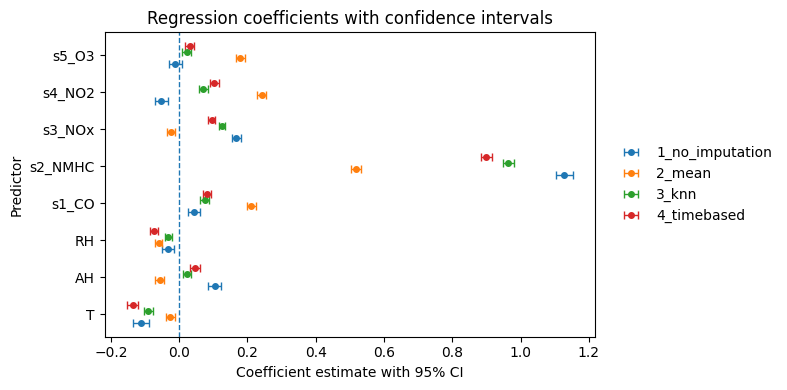

In [59]:
# Koeffizienten vergleichen
# Teilweise stark unterschiedlich
# Wir schließen const (=Intercept) beim Plot aus
regression.plot_coef_compare(models_mcar, model_names, exclude="const")

Die Sensitivitätsanalyse zeigt, dass einige Koeffizienten robust gegenüber der Imputationsmethode sind, andere jedoch stark von der gewählten Methode abhängen. 

Die Mittelwert-Imputation liegt meist weiter weg -- ein deutliches Zeichen, dass sie für Zeitreihen nicht so geeignet ist.

NO2 wechselt das Vorzeichen: hier muss mit Domänenwissen genauer hingeschaut werden.

In [60]:
# Modell 1 (Complete Case Analyses) verwendet nur jene Zeilen in denen
# kein einziger Wert fehlt --> es fallen über 3/4 der Daten weg!
# Bei MCAR ist das grundsätzlich unverzerrt, aber oft ineffizient:
# Es gehen viele Daten verloren, dadurch können Koeffizienten stärker schwanken.
# Modell 1 ist daher ein sinnvoller Referenzpunkt, aber nicht automatisch die Wahrheit.

models_mcar[0].nobs

2514.0

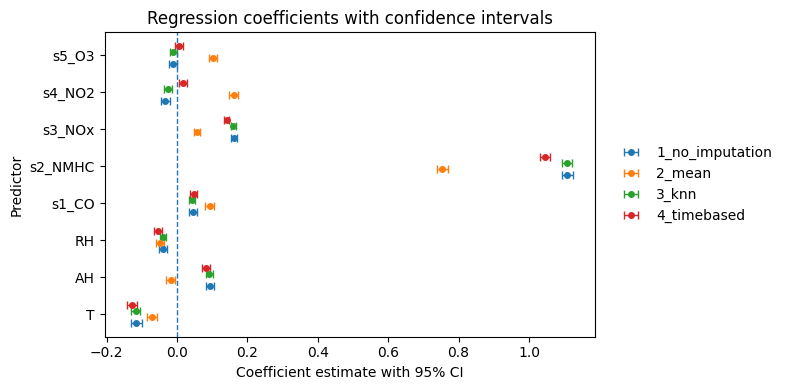

In [61]:
# Wenn weniger Daten fehlen (z.B. 4% statt 15%) schwanken auch die Koeffizienten weniger.

df_mcar2 = make_mcar(dfz, missing_rate=0.04)
models_mcar2, model_names = run_missingness_experiment(df_mcar2)
regression.plot_coef_compare(models_mcar2, model_names, exclude="const")

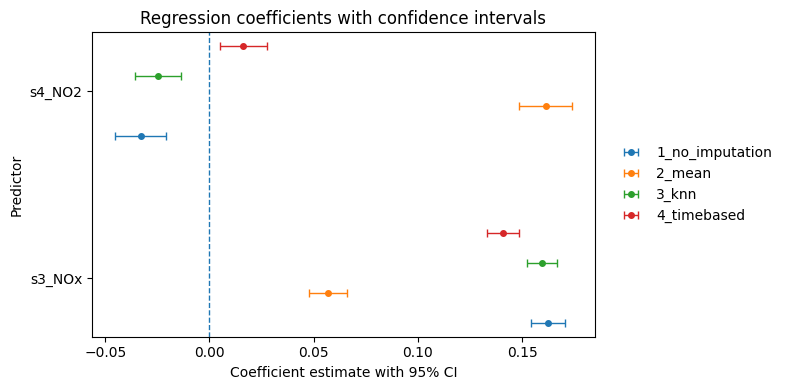

In [62]:
# Detailansicht von NO2 und NOx
regression.plot_coef_compare(models_mcar2, model_names, filter="NO")

Die Sensitivitätsanalyse zeigt, dass der geschätzte Effekt von NOx über die meisten Imputationsvarianten hinweg stabil bleibt. Dies spricht dafür, dass die Interpretation von NOx weniger stark von der gewählten Imputationsmethode abhängt. 

NO2 zeigt zwar einen Vorzeichenwechsel zwischen Complete-Case-Analyse und 2 von 3 imputierten Modellen, die Koeffizienten liegen jedoch nahe bei Null. Daher ist weniger der Vorzeichenwechsel selbst relevant, sondern eher die Schlussfolgerung, dass NO2 in diesem Modell keinen robust interpretierbaren eigenständigen Effekt zeigt.

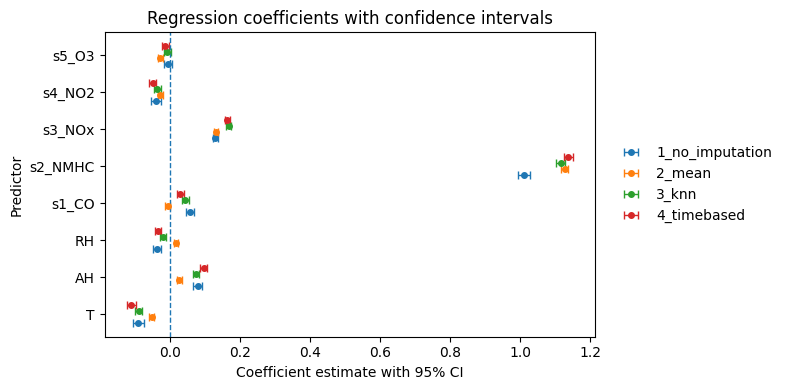

In [64]:
# Missing at Random: fehlende Werte hängen von anderer Variable ab.
# Bei uns: von s2_NMHC
df_mar = make_mar(dfz)
models_mar, model_names = run_missingness_experiment(df_mar)
regression.plot_coef_compare(models_mar, model_names, exclude="const")

# Obwohl keine Daten bei NMHC fehlen, ändert sich der Koeffizient,
# weil mehr Daten dazukommen und zur Verfügung stehen.

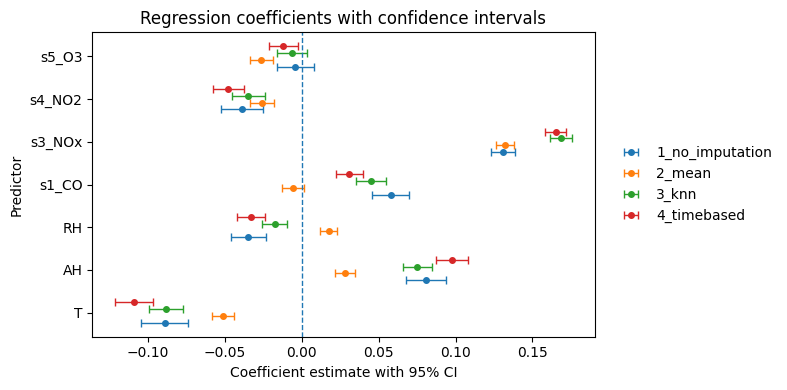

In [65]:
# Detailansicht ohne NMHC:
regression.plot_coef_compare(models_mar, model_names, exclude="const|NMHC")

Einige Koeffizienten sind nun deutlich stabiler, d.h. weniger sensitiv, bspw. NO2, NOx, O3, RH. Nur Mitelwert-Imputation weicht stark ab.

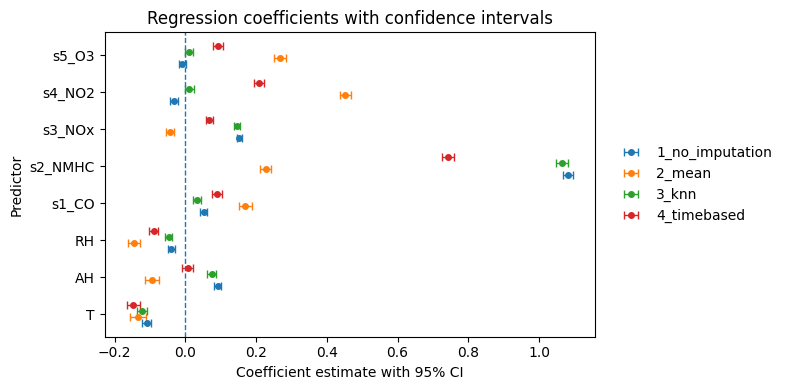

In [66]:
# Bei MNAR fehlen nur Daten in der Spalte in NMHC.
# Alle anderen Variablen sind vollständig.
# Aber es fehlen mehr hohe Werte von NMHC als niedrige Werte
df_mnar = make_mnar(dfz)
models_mnar, model_names = run_missingness_experiment(df_mnar)

regression.plot_coef_compare(models_mnar, model_names, exclude="const")

NMHC ist stark sensitiv in Bezug auf die Wahl der Imputationsmethode. Ob nun KNN oder zeitbasierte Interpolation sinnvoller ist, müsste durch zusätzliche Analyse geklärt werden.

Auch die anderen Koeffizienten variieren recht stark. Hintergrund ist hier, dass NMHC einen so starken Effekt hat, (die anderen einen relativ kleinen), dass es sich eine Änderung bei NMHC auf alle anderen Koeffizienten mitüberträgt.